# HSHL ADAS — CARLA Dataset + README-Based Solution

This notebook is built for the README requirements only.

Main points:
- CARLA-based Kaggle dataset: `ibrahimalobaid/object-detection-carla-self-driving-car`
- Required file created: `solution/my_adas.py`
- Required functions implemented:
  1. `detect_traffic_light(image)`
  2. `detect_objects(image)`
  3. `compute_control(speed_kmh)`
- Camera + speed are used.
- LiDAR is not used because the README says LiDAR is not available.
- Pedestrian braking is included using the CARLA dataset class `person`.

Run cells from top to bottom.

In [2]:


!pip install -q ultralytics opencv-python-headless

import os
import cv2
import shutil
import zipfile
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
import sys
import importlib.util

print("Setup done.")
print("Pandas version:", pd.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 75.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Setup done.
Pandas version: 2.2.2


In [3]:
# Cell 2 — Kaggle authentication
# Type 'token' if Kaggle gave you a KGAT_... token.
# Type 'json' if you have a kaggle.json file.

from pathlib import Path
from getpass import getpass

kaggle_dir = Path.home() / ".kaggle"
kaggle_dir.mkdir(parents=True, exist_ok=True)

auth_method = input("Choose Kaggle auth method: type 'json' for kaggle.json upload or 'token' for KGAT token: ").strip().lower()

if auth_method == "token":
    token = getpass("Paste your Kaggle API token starting with KGAT_ here: ").strip()
    if not token.startswith("KGAT_"):
        print("[WARN] This does not look like the new KGAT token format. Continuing anyway.")
    (kaggle_dir / "access_token").write_text(token, encoding="utf-8")
    (kaggle_dir / "access_token").chmod(0o600)
    os.environ["KAGGLE_API_TOKEN"] = token
    print("Kaggle KGAT token configured.")

elif auth_method == "json":
    try:
        from google.colab import files
        uploaded = files.upload()
        if "kaggle.json" not in uploaded:
            raise FileNotFoundError("kaggle.json was not uploaded.")
        shutil.copy("kaggle.json", kaggle_dir / "kaggle.json")
        (kaggle_dir / "kaggle.json").chmod(0o600)
        print("kaggle.json configured.")
    except Exception as e:
        raise RuntimeError(f"Could not configure kaggle.json: {e}")

else:
    raise ValueError("Please type exactly: token or json")

print("Testing Kaggle command...")
!kaggle datasets list -s carla -m | head

Choose Kaggle auth method: type 'json' for kaggle.json upload or 'token' for KGAT token: token
Paste your Kaggle API token starting with KGAT_ here: ··········
Kaggle KGAT token configured.
Testing Kaggle command...
No datasets found


In [4]:
# Cell 3 — Download the CARLA Kaggle dataset

DATASET_SLUG = "ibrahimalobaid/object-detection-carla-self-driving-car"

RAW_DIR = Path("/content/carla_kaggle_raw")
ZIP_DIR = Path("/content/kaggle_zip")
PREPARED_DIR = Path("/content/hshl_carla_yolo_dataset")
RUN_DIR = Path("/content/hshl_yolo_runs")
BASE_DIR = Path("/content/hshl_adas_project")
SOLUTION_DIR = BASE_DIR / "solution"

for d in [RAW_DIR, ZIP_DIR, PREPARED_DIR, RUN_DIR, BASE_DIR, SOLUTION_DIR]:
    d.mkdir(parents=True, exist_ok=True)

for d in [RAW_DIR, PREPARED_DIR]:
    if d.exists():
        shutil.rmtree(d)
    d.mkdir(parents=True, exist_ok=True)

print("Downloading:", DATASET_SLUG)
!kaggle datasets download -d {DATASET_SLUG} -p {ZIP_DIR} --force

zip_files = list(ZIP_DIR.glob("*.zip"))
if not zip_files:
    raise FileNotFoundError("No Kaggle zip file downloaded.")

zip_path = max(zip_files, key=lambda p: p.stat().st_mtime)
print("Unzipping:", zip_path)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(RAW_DIR)

print("Dataset extracted to:", RAW_DIR)
print("Top-level files/folders:")
for p in sorted(RAW_DIR.iterdir()):
    print(" -", p)

Downloading: ibrahimalobaid/object-detection-carla-self-driving-car
Dataset URL: https://www.kaggle.com/datasets/ibrahimalobaid/object-detection-carla-self-driving-car
License(s): Attribution 4.0 International (CC BY 4.0)
100% 27.1M/27.1M [00:03<00:00, 9.40MB/s]

Unzipping: /content/kaggle_zip/object-detection-carla-self-driving-car.zip
Dataset extracted to: /content/carla_kaggle_raw
Top-level files/folders:
 - /content/carla_kaggle_raw/README.dataset.txt
 - /content/carla_kaggle_raw/README.roboflow.txt
 - /content/carla_kaggle_raw/data.yaml
 - /content/carla_kaggle_raw/test
 - /content/carla_kaggle_raw/train
 - /content/carla_kaggle_raw/valid


In [5]:
# Cell 4 — Inspect CARLA dataset structure

def print_tree(root: Path, max_depth=4):
    root = Path(root)
    for current, dirs, files in os.walk(root):
        current = Path(current)
        depth = len(current.relative_to(root).parts)
        if depth > max_depth:
            dirs[:] = []
            continue
        indent = "  " * depth
        print(f"{indent}{current.name}/")
        shown = files[:5]
        for f in shown:
            print(f"{indent}  {f}")
        if len(files) > 5:
            print(f"{indent}  ... {len(files)-5} more files")

print_tree(RAW_DIR, max_depth=4)

carla_kaggle_raw/
  README.roboflow.txt
  data.yaml
  README.dataset.txt
  train/
    labels/
      1589_jpg.rf.be751db6e679886c9d57c106f863676d.txt
      37_jpg.rf.f2264a20935db8e72d9cc3432dffbce9.txt
      1132_jpg.rf.27e54c682b01faf729d760c7f655d402.txt
      526_jpg.rf.c169d945011285a2eed6af754ba8a640.txt
      1113_jpg.rf.dfc01d7cf6984588a5d3d1cbc110c413.txt
      ... 1115 more files
    images/
      313_jpg.rf.7cec418a6429975b9278b8a57c9fe73e.jpg
      321_jpg.rf.7c586e504ffcf7752b65bfc9be617a85.jpg
      1015_jpg.rf.24683b1108bea567a2dc0d1699609fc2.jpg
      1355_jpg.rf.22dc867bb2f9fcca3701b6e5b2a97f9e.jpg
      759_jpg.rf.124efbe9db330faaad2ae5b8078353e0.jpg
      ... 1115 more files
  test/
    labels/
      437_jpg.rf.6f51a180ea1e95cb5a8b29fce3cf2f54.txt
      974_jpg.rf.6998e6a51a8b17eeba682bf504ca6f77.txt
      539_jpg.rf.19e46e5240a3cc70649a94984ef860ff.txt
      626_jpg.rf.cce8a641216a86dec3d9df07ecc67f72.txt
      224_jpg.rf.43f66a1619536a66032b3999d2bd355a.txt
      ..

In [6]:
# Cell 5 — Prepare clean YOLO dataset from CARLA dataset

import yaml

DEFAULT_CLASS_NAMES_10 = [
    "bike",
    "motobike",
    "person",
    "traffic_light_green",
    "traffic_light_orange",
    "traffic_light_red",
    "traffic_sign_30",
    "traffic_sign_60",
    "traffic_sign_90",
    "vehicle",
]

IMAGE_EXTS = [".jpg", ".jpeg", ".png", ".bmp"]

def list_images(folder: Path):
    out = []
    for ext in IMAGE_EXTS:
        out.extend(folder.glob(f"*{ext}"))
        out.extend(folder.glob(f"*{ext.upper()}"))
    return sorted(out)

def count_label_lines(label_dir: Path):
    n_files = 0
    n_lines = 0
    if not label_dir.exists():
        return 0, 0
    for lf in label_dir.glob("*.txt"):
        n_files += 1
        try:
            lines = [ln.strip() for ln in lf.read_text(errors="ignore").splitlines() if ln.strip()]
            n_lines += len(lines)
        except Exception:
            pass
    return n_files, n_lines

def read_class_names(root: Path):
    for yf in list(root.rglob("*.yaml")) + list(root.rglob("*.yml")):
        try:
            cfg = yaml.safe_load(yf.read_text())
            if isinstance(cfg, dict) and "names" in cfg:
                names = cfg["names"]
                if isinstance(names, dict):
                    names = [names[k] for k in sorted(names.keys(), key=lambda x: int(x) if str(x).isdigit() else str(x))]
                names = [str(n) for n in names]
                if len(names) >= 2:
                    print("Class names loaded from YAML:", yf)
                    return names
        except Exception:
            pass

    for tf in list(root.rglob("labels.txt")) + list(root.rglob("classes.txt")) + list(root.rglob("obj.names")):
        try:
            lines = [ln.strip() for ln in tf.read_text(errors="ignore").splitlines() if ln.strip()]
            if len(lines) >= 2:
                print("Class names loaded from text:", tf)
                return lines
        except Exception:
            pass

    print("Using default 10 CARLA class names.")
    return DEFAULT_CLASS_NAMES_10

def find_image_folders(root: Path):
    image_folders = []
    for folder in root.rglob("*"):
        if folder.is_dir() and len(list_images(folder)) > 0:
            image_folders.append(folder)
    return sorted(set(image_folders), key=lambda p: str(p))

def split_score(path: Path, split_words):
    parts = [p.lower() for p in path.parts]
    s = str(path).lower().replace("\\", "/")
    score = 0
    for w in split_words:
        if w in parts:
            score += 3
        if f"/{w}/" in s or s.endswith(f"/{w}"):
            score += 2
        if w in path.name.lower():
            score += 1
    return score

def choose_split_folder(image_folders, split_words):
    scored = [(split_score(p, split_words), p) for p in image_folders]
    scored = [x for x in scored if x[0] > 0]
    if not scored:
        return None
    scored.sort(key=lambda x: (-x[0], str(x[1])))
    return scored[0][1]

def label_candidates_for_image_folder(img_dir: Path):
    candidates = []
    candidates.append(img_dir.parent / "labels")
    candidates.append(img_dir.parent / "yolo_labels")
    candidates.append(img_dir.parent.parent / "labels" / img_dir.name)
    candidates.append(img_dir.parent.parent / "yolo_labels" / img_dir.name)

    parts = list(img_dir.parts)
    for i, part in enumerate(parts):
        if part.lower() == "images":
            candidates.append(Path(*parts[:i], "labels", *parts[i+1:]))
            candidates.append(Path(*parts[:i], "yolo_labels", *parts[i+1:]))

    out = []
    for c in candidates:
        if c not in out:
            out.append(c)
    return out

def choose_label_folder(img_dir: Path):
    candidates = label_candidates_for_image_folder(img_dir)
    best = None
    best_score = -1

    image_stems = {p.stem for p in list_images(img_dir)}
    for cand in candidates:
        if not cand.exists() or not cand.is_dir():
            continue
        label_files = list(cand.glob("*.txt"))
        if not label_files:
            continue
        label_stems = {p.stem for p in label_files}
        overlap = len(image_stems & label_stems)
        _, label_lines = count_label_lines(cand)
        score = overlap * 10 + label_lines
        if score > best_score:
            best = cand
            best_score = score

    return best

def copy_split(src_img_dir: Path, src_lbl_dir: Path, split_name: str):
    dst_img_dir = PREPARED_DIR / split_name / "images"
    dst_lbl_dir = PREPARED_DIR / split_name / "labels"
    dst_img_dir.mkdir(parents=True, exist_ok=True)
    dst_lbl_dir.mkdir(parents=True, exist_ok=True)

    images = list_images(src_img_dir)
    copied_images = 0
    copied_labels = 0
    label_lines = 0

    for img in images:
        shutil.copy2(img, dst_img_dir / img.name)
        copied_images += 1

        src_lbl = src_lbl_dir / f"{img.stem}.txt"
        if src_lbl.exists():
            shutil.copy2(src_lbl, dst_lbl_dir / src_lbl.name)
            copied_labels += 1
            lines = [ln.strip() for ln in src_lbl.read_text(errors="ignore").splitlines() if ln.strip()]
            label_lines += len(lines)
        else:
            (dst_lbl_dir / f"{img.stem}.txt").write_text("", encoding="utf-8")

    return copied_images, copied_labels, label_lines

if PREPARED_DIR.exists():
    shutil.rmtree(PREPARED_DIR)
PREPARED_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = read_class_names(RAW_DIR)
print("Class names:", CLASS_NAMES)

image_folders = find_image_folders(RAW_DIR)

print("\\nImage folders found:")
for f in image_folders:
    print(" ", f, "->", len(list_images(f)), "images")

if not image_folders:
    raise FileNotFoundError("No image folders found in the downloaded CARLA dataset.")

train_img_dir = choose_split_folder(image_folders, ["train", "training"])
valid_img_dir = choose_split_folder(image_folders, ["valid", "val", "validation"])
test_img_dir = choose_split_folder(image_folders, ["test", "testing"])

if train_img_dir is None:
    raise FileNotFoundError("Could not identify a train image folder.")

if valid_img_dir is None:
    print("No validation split found. Using test split as validation.")
    valid_img_dir = test_img_dir

if test_img_dir is None:
    print("No test split found. Using validation split as test.")
    test_img_dir = valid_img_dir

if valid_img_dir is None or test_img_dir is None:
    valid_img_dir = train_img_dir
    test_img_dir = train_img_dir

split_sources = {
    "train": train_img_dir,
    "valid": valid_img_dir,
    "test": test_img_dir,
}

print("\\nSelected image folders:")
for split, img_dir in split_sources.items():
    print(split, ":", img_dir)

split_labels = {}
for split, img_dir in split_sources.items():
    lbl_dir = choose_label_folder(img_dir)
    if lbl_dir is None:
        raise FileNotFoundError(f"Could not find YOLO .txt labels for split {split} image folder {img_dir}")
    split_labels[split] = lbl_dir
    files, lines = count_label_lines(lbl_dir)
    print(f"{split} labels: {lbl_dir} -> {files} txt files, {lines} object lines")

print("\\nCopying into clean YOLO structure...")
summary = {}
for split in ["train", "valid", "test"]:
    summary[split] = copy_split(split_sources[split], split_labels[split], split)

print("\\nPrepared split summary:")
for split, (n_img, n_lbl, n_lines) in summary.items():
    print(f"{split:5s}: images={n_img}, labels={n_lbl}, object_lines={n_lines}")

if summary["train"][2] == 0:
    raise RuntimeError("Training labels have 0 object lines. Labels were not connected correctly.")

DATA_YAML = PREPARED_DIR / "data.yaml"
data_cfg = {
    "train": str(PREPARED_DIR / "train" / "images"),
    "val": str(PREPARED_DIR / "valid" / "images"),
    "test": str(PREPARED_DIR / "test" / "images"),
    "nc": len(CLASS_NAMES),
    "names": CLASS_NAMES,
}

DATA_YAML.write_text(yaml.dump(data_cfg, sort_keys=False), encoding="utf-8")

print("\\nYOLO data.yaml created:")
print(DATA_YAML)
print(DATA_YAML.read_text())

Class names loaded from YAML: /content/carla_kaggle_raw/data.yaml
Class names: ['bike', 'motobike', 'person', 'traffic_light_green', 'traffic_light_orange', 'traffic_light_red', 'traffic_sign_30', 'traffic_sign_60', 'traffic_sign_90', 'vehicle']
\nImage folders found:
  /content/carla_kaggle_raw/test/images -> 160 images
  /content/carla_kaggle_raw/train/images -> 1120 images
  /content/carla_kaggle_raw/valid/images -> 320 images
\nSelected image folders:
train : /content/carla_kaggle_raw/train/images
valid : /content/carla_kaggle_raw/valid/images
test : /content/carla_kaggle_raw/test/images
train labels: /content/carla_kaggle_raw/train/labels -> 1120 txt files, 2028 object lines
valid labels: /content/carla_kaggle_raw/valid/labels -> 320 txt files, 557 object lines
test labels: /content/carla_kaggle_raw/test/labels -> 160 txt files, 292 object lines
\nCopying into clean YOLO structure...
\nPrepared split summary:
train: images=1120, labels=1120, object_lines=2028
valid: images=320, la

one shot merge train

In [7]:
!pip install -q ultralytics pyyaml

from google.colab import files
from pathlib import Path
from ultralytics import YOLO
import shutil
import zipfile
import yaml

# ---------------------------------------------------------------------------
# 1. Upload normalized lab dataset - FIXED
# ---------------------------------------------------------------------------

uploaded = files.upload()
zip_name = next(name for name in uploaded if name.endswith(".zip"))

LAB_ZIP = Path("/content") / zip_name
LAB_ROOT_PARENT = Path("/content/lab_data")

if LAB_ROOT_PARENT.exists():
    shutil.rmtree(LAB_ROOT_PARENT)
LAB_ROOT_PARENT.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(LAB_ZIP, "r") as zf:
    for member in zf.infolist():
        fixed_name = member.filename.replace("\\", "/")

        if not fixed_name or fixed_name.endswith("/"):
            continue

        target_path = LAB_ROOT_PARENT / fixed_name
        target_path.parent.mkdir(parents=True, exist_ok=True)

        with zf.open(member) as src, open(target_path, "wb") as dst:
            shutil.copyfileobj(src, dst)

data_yaml_candidates = list(LAB_ROOT_PARENT.rglob("data.yaml"))

if not data_yaml_candidates:
    print("Extracted files:")
    for p in list(LAB_ROOT_PARENT.rglob("*"))[:150]:
        print(p)
    raise FileNotFoundError("Could not find extracted lab dataset with data.yaml.")

LAB_DIR = data_yaml_candidates[0].parent

print("LAB_DIR:", LAB_DIR)
print((LAB_DIR / "data.yaml").read_text())


# ---------------------------------------------------------------------------
# 2. Merge Kaggle CARLA data + lab data
# ---------------------------------------------------------------------------

# IMPORTANT:
# Your previous notebook must already have:
# PREPARED_DIR = Path("/content/hshl_carla_yolo_dataset")

MERGED_DIR = Path("/content/hshl_carla_plus_lab_yolo")
if MERGED_DIR.exists():
    shutil.rmtree(MERGED_DIR)

for split in ["train", "valid", "test"]:
    (MERGED_DIR / split / "images").mkdir(parents=True, exist_ok=True)
    (MERGED_DIR / split / "labels").mkdir(parents=True, exist_ok=True)

CLASS_NAMES = [
    "bike",
    "motobike",
    "person",
    "traffic_light_green",
    "traffic_light_orange",
    "traffic_light_red",
    "traffic_sign_30",
    "traffic_sign_60",
    "traffic_sign_90",
    "vehicle",
]

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}


def copy_yolo_split(src_root, src_split, dst_split, prefix):
    src_root = Path(src_root)
    src_img_dir = src_root / src_split / "images"
    src_lbl_dir = src_root / src_split / "labels"
    dst_img_dir = MERGED_DIR / dst_split / "images"
    dst_lbl_dir = MERGED_DIR / dst_split / "labels"

    if not src_img_dir.exists():
        print(f"Missing split, skipped: {src_img_dir}")
        return 0

    copied = 0
    for image_path in sorted(src_img_dir.iterdir()):
        if image_path.suffix.lower() not in IMAGE_EXTS:
            continue

        new_stem = f"{prefix}_{image_path.stem}"
        shutil.copy2(image_path, dst_img_dir / f"{new_stem}{image_path.suffix.lower()}")

        src_label = src_lbl_dir / f"{image_path.stem}.txt"
        dst_label = dst_lbl_dir / f"{new_stem}.txt"

        if src_label.exists():
            shutil.copy2(src_label, dst_label)
        else:
            dst_label.write_text("")

        copied += 1

    return copied


counts = {
    "kaggle_train": copy_yolo_split(PREPARED_DIR, "train", "train", "kaggle"),
    "kaggle_valid": copy_yolo_split(PREPARED_DIR, "valid", "valid", "kaggle"),
    "kaggle_test": copy_yolo_split(PREPARED_DIR, "test", "test", "kaggle"),
    "lab_train": copy_yolo_split(LAB_DIR, "train", "train", "lab"),
    "lab_valid": copy_yolo_split(LAB_DIR, "valid", "valid", "lab"),
    "lab_test": copy_yolo_split(LAB_DIR, "test", "test", "lab"),
}

MERGED_YAML = MERGED_DIR / "data.yaml"
MERGED_YAML.write_text(
    yaml.safe_dump(
        {
            "train": str(MERGED_DIR / "train" / "images"),
            "val": str(MERGED_DIR / "valid" / "images"),
            "test": str(MERGED_DIR / "test" / "images"),
            "nc": len(CLASS_NAMES),
            "names": CLASS_NAMES,
        },
        sort_keys=False,
    ),
    encoding="utf-8",
)

print("Merged counts:", counts)
print(MERGED_YAML.read_text())


# ---------------------------------------------------------------------------
# 3. Train YOLO with mosaic + scale augmentation
# ---------------------------------------------------------------------------

RUN_DIR = Path("/content/hshl_yolo_runs_plus_lab")
if RUN_DIR.exists():
    shutil.rmtree(RUN_DIR)

EPOCHS = 60
IMG_SIZE = 640
BATCH_SIZE = 16
BASE_MODEL = "yolov8n.pt"

model = YOLO(BASE_MODEL)

model.train(
    data=str(MERGED_YAML),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    project=str(RUN_DIR),
    name="hshl_carla_plus_lab_yolov8n_augmented",
    exist_ok=True,
    patience=12,

    mosaic=1.0,
    close_mosaic=10,
    scale=0.50,

    verbose=True,
    plots=True,
)

best_candidates = list(RUN_DIR.rglob("best.pt"))
if not best_candidates:
    raise FileNotFoundError("Training finished, but no best.pt was found.")

BEST_WEIGHTS = max(best_candidates, key=lambda p: p.stat().st_mtime)
print("BEST_WEIGHTS:", BEST_WEIGHTS)


# ---------------------------------------------------------------------------
# 4. Download final model
# ---------------------------------------------------------------------------

FINAL_MODEL = Path("/content/best.pt")
shutil.copy2(BEST_WEIGHTS, FINAL_MODEL)

files.download(str(FINAL_MODEL))

print("Downloaded model as best.pt")
print("Upload this file to GitHub at: solution/best.pt")

Saving lab_yolo_10class_ready.zip to lab_yolo_10class_ready.zip
LAB_DIR: /content/lab_data/lab_yolo_10class_ready
train: train/images
val: valid/images
test: test/images
nc: 10
names:
  0: bike
  1: motobike
  2: person
  3: traffic_light_green
  4: traffic_light_orange
  5: traffic_light_red
  6: traffic_sign_30
  7: traffic_sign_60
  8: traffic_sign_90
  9: vehicle

Merged counts: {'kaggle_train': 1120, 'kaggle_valid': 320, 'kaggle_test': 160, 'lab_train': 167, 'lab_valid': 33, 'lab_test': 22}
train: /content/hshl_carla_plus_lab_yolo/train/images
val: /content/hshl_carla_plus_lab_yolo/valid/images
test: /content/hshl_carla_plus_lab_yolo/test/images
nc: 10
names:
- bike
- motobike
- person
- traffic_light_green
- traffic_light_orange
- traffic_light_red
- traffic_sign_30
- traffic_sign_60
- traffic_sign_90
- vehicle

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=ra

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded model as best.pt
Upload this file to GitHub at: solution/best.pt


Compaarative analysis between three models of yolo8


Training YOLOv8n: Nano: fastest, smallest
Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=5, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/hshl_carla_plus_lab_yolo/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv8n_merged_aug, nbs=64, nms=False, opset=Non

,model,description,epochs,precision,recall,mAP50,mAP50-95,preprocess_ms,inference_ms,postprocess_ms,total_ms_per_image,approx_fps,model_size_MB,training_time_min,weights_path
0,YOLOv8n,"Nano: fastest, smallest",30,0.896647,0.853261,0.888011,0.650651,1.664212,4.926714,1.571880,8.162806,122.506887,5.960917,14.946792,/content/yolo8_model_comparison/YOLOv8n_merged...
1,YOLOv8s,Small: balanced speed and accuracy,30,0.920832,0.843631,0.899368,0.666972,2.918443,11.103249,1.212609,15.234300,65.641349,21.479532,16.225816,/content/yolo8_model_comparison/YOLOv8s_merged...
2,YOLOv8m,"Medium: higher accuracy, slower",30,0.891566,0.877914,0.904697,0.683415,2.051033,24.837401,2.039109,28.927543,34.569130,49.627337,36.001447,/content/yolo8_model_comparison/YOLOv8m_merged...


,model,class_id,class_name,class_mAP50-95
0,YOLOv8n,0,bike,0.513694
1,YOLOv8n,1,motobike,0.555340
2,YOLOv8n,2,person,0.714807
3,YOLOv8n,3,traffic_light_green,0.593415
4,YOLOv8n,4,traffic_light_orange,0.413858
5,YOLOv8n,5,traffic_light_red,0.545798
6,YOLOv8n,6,traffic_sign_30,0.833360
7,YOLOv8n,7,traffic_sign_60,0.789833
8,YOLOv8n,8,traffic_sign_90,0.895500
9,YOLOv8n,9,vehicle,0.650906


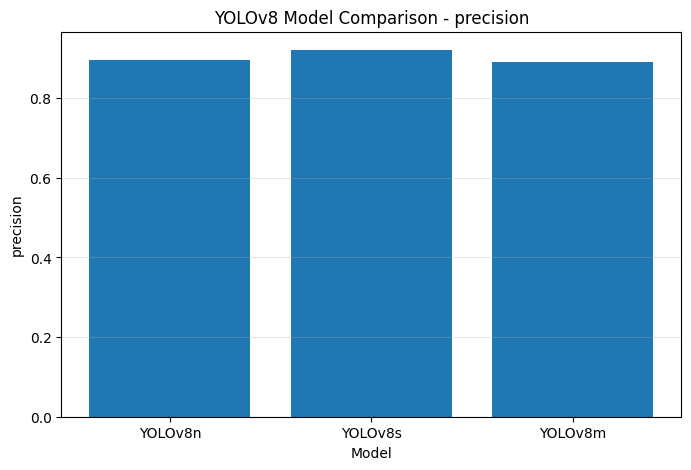

Saved: /content/yolo8_model_comparison/comparison_precision.png


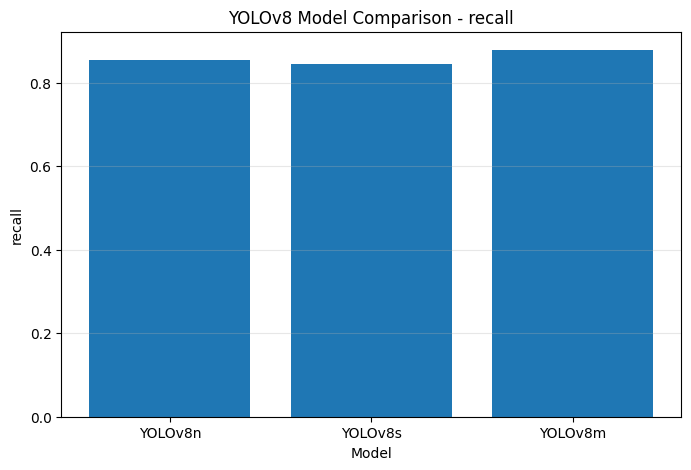

Saved: /content/yolo8_model_comparison/comparison_recall.png


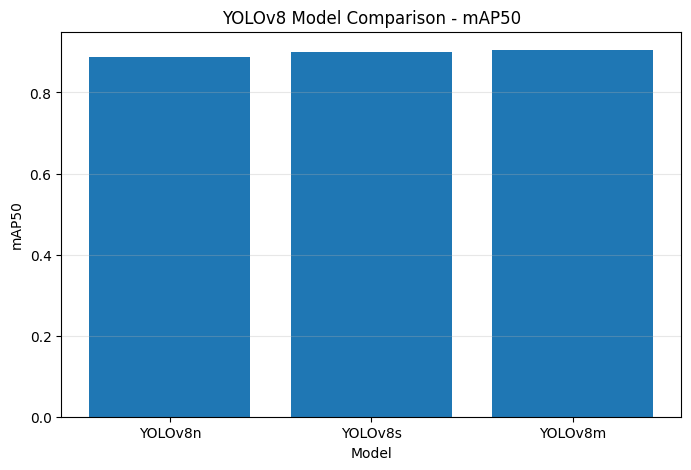

Saved: /content/yolo8_model_comparison/comparison_mAP50.png


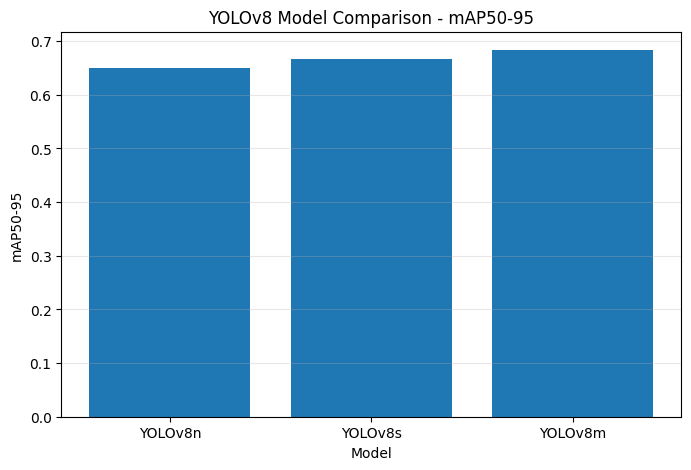

Saved: /content/yolo8_model_comparison/comparison_mAP50-95.png


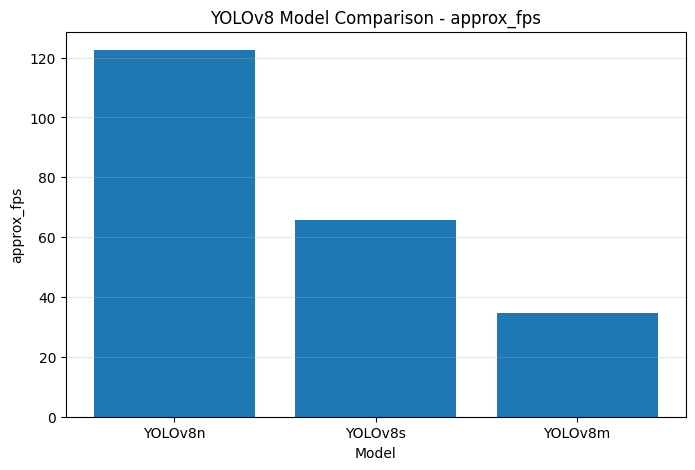

Saved: /content/yolo8_model_comparison/comparison_approx_fps.png


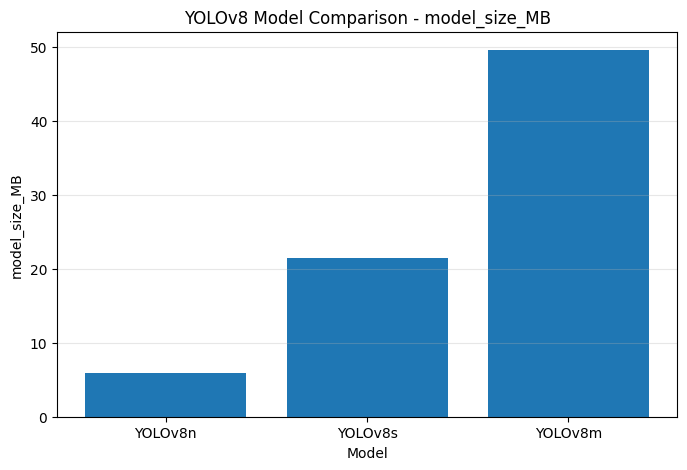

Saved: /content/yolo8_model_comparison/comparison_model_size_MB.png


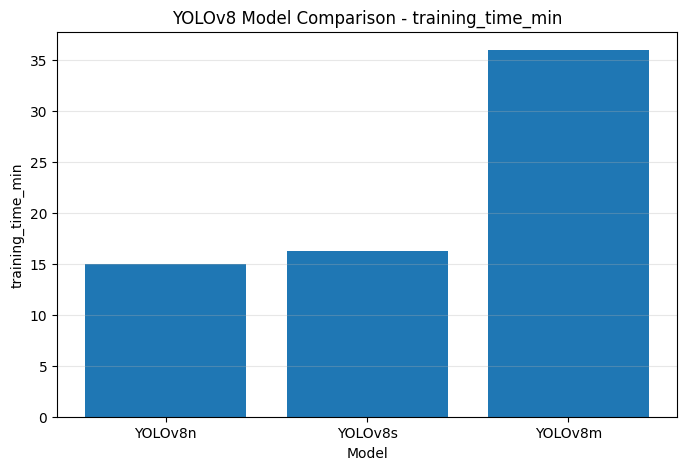

Saved: /content/yolo8_model_comparison/comparison_training_time_min.png

ADAS ranking:


,model,precision,recall,mAP50,mAP50-95,approx_fps,model_size_MB,training_time_min,adas_score
0,YOLOv8n,0.896647,0.853261,0.888011,0.650651,122.506887,5.960917,14.946792,0.968598
1,YOLOv8s,0.920832,0.843631,0.899368,0.666972,65.641349,21.479532,16.225816,0.882669
2,YOLOv8m,0.891566,0.877914,0.904697,0.683415,34.569130,49.627337,36.001447,0.856436



Recommended model for ADAS:
YOLOv8n
Weights path:
/content/yolo8_model_comparison/YOLOv8n_merged_aug/weights/best.pt


In [8]:
from ultralytics import YOLO
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import time

# Uses merged dataset from the one-shot cell
MERGED_YAML = Path(MERGED_YAML)

if not MERGED_YAML.exists():
    raise FileNotFoundError(f"MERGED_YAML not found: {MERGED_YAML}")

COMPARISON_DIR = Path("/content/yolo8_model_comparison")
COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

models_to_compare = [
    {
        "model_file": "yolov8n.pt",
        "model_name": "YOLOv8n",
        "description": "Nano: fastest, smallest"
    },
    {
        "model_file": "yolov8s.pt",
        "model_name": "YOLOv8s",
        "description": "Small: balanced speed and accuracy"
    },
    {
        "model_file": "yolov8m.pt",
        "model_name": "YOLOv8m",
        "description": "Medium: higher accuracy, slower"
    },
]

EPOCHS = 30
IMG_SIZE = 640
BATCH_SIZE = 8

comparison_rows = []
classwise_rows = []

for cfg in models_to_compare:
    model_file = cfg["model_file"]
    model_name = cfg["model_name"]
    run_name = f"{model_name}_merged_aug"

    print("\n" + "=" * 80)
    print(f"Training {model_name}: {cfg['description']}")
    print("=" * 80)

    model = YOLO(model_file)

    start_time = time.time()

    model.train(
        data=str(MERGED_YAML),
        epochs=EPOCHS,
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        project=str(COMPARISON_DIR),
        name=run_name,
        exist_ok=True,
        patience=5,

        # same augmentation idea as your final model
        mosaic=1.0,
        close_mosaic=5,
        scale=0.50,

        verbose=True,
        plots=True,
    )

    training_time_sec = time.time() - start_time

    weights_path = COMPARISON_DIR / run_name / "weights" / "best.pt"
    if not weights_path.exists():
        raise FileNotFoundError(f"best.pt not found for {model_name}: {weights_path}")

    trained_model = YOLO(str(weights_path))

    print(f"\nValidating {model_name} on merged test data...")

    metrics = trained_model.val(
        data=str(MERGED_YAML),
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        split="test",
        verbose=False,
    )

    precision = float(metrics.box.mp)
    recall = float(metrics.box.mr)
    map50 = float(metrics.box.map50)
    map50_95 = float(metrics.box.map)

    speed_info = metrics.speed
    preprocess_ms = float(speed_info.get("preprocess", 0.0))
    inference_ms = float(speed_info.get("inference", 0.0))
    postprocess_ms = float(speed_info.get("postprocess", 0.0))
    total_ms = preprocess_ms + inference_ms + postprocess_ms
    fps = 1000.0 / total_ms if total_ms > 0 else 0.0

    model_size_mb = weights_path.stat().st_size / (1024 * 1024)

    comparison_rows.append({
        "model": model_name,
        "description": cfg["description"],
        "epochs": EPOCHS,
        "precision": precision,
        "recall": recall,
        "mAP50": map50,
        "mAP50-95": map50_95,
        "preprocess_ms": preprocess_ms,
        "inference_ms": inference_ms,
        "postprocess_ms": postprocess_ms,
        "total_ms_per_image": total_ms,
        "approx_fps": fps,
        "model_size_MB": model_size_mb,
        "training_time_min": training_time_sec / 60.0,
        "weights_path": str(weights_path),
    })

    if hasattr(metrics.box, "maps"):
        names = metrics.names
        for class_id, class_map in enumerate(metrics.box.maps):
            class_name = names[class_id] if isinstance(names, dict) else names[class_id]
            classwise_rows.append({
                "model": model_name,
                "class_id": class_id,
                "class_name": class_name,
                "class_mAP50-95": float(class_map),
            })

comparison_df = pd.DataFrame(comparison_rows)
classwise_df = pd.DataFrame(classwise_rows)

comparison_csv = COMPARISON_DIR / "yolo8_model_comparison_summary.csv"
classwise_csv = COMPARISON_DIR / "yolo8_classwise_comparison.csv"

comparison_df.to_csv(comparison_csv, index=False)
classwise_df.to_csv(classwise_csv, index=False)

print("\nComparison complete.")
print("Saved:", comparison_csv)
print("Saved:", classwise_csv)

display(comparison_df)
display(classwise_df)


# ---------------------------------------------------------------------------
# Plot comparison graphs
# ---------------------------------------------------------------------------

metrics_to_plot = [
    "precision",
    "recall",
    "mAP50",
    "mAP50-95",
    "approx_fps",
    "model_size_MB",
    "training_time_min",
]

for metric in metrics_to_plot:
    plt.figure(figsize=(8, 5))
    plt.bar(comparison_df["model"], comparison_df[metric])
    plt.title(f"YOLOv8 Model Comparison - {metric}")
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.grid(axis="y", alpha=0.3)

    output_path = COMPARISON_DIR / f"comparison_{metric}.png"
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved:", output_path)


# ---------------------------------------------------------------------------
# Select best model for ADAS
# ---------------------------------------------------------------------------

df = comparison_df.copy()

df["normalized_mAP50_95"] = df["mAP50-95"] / df["mAP50-95"].max()
df["normalized_recall"] = df["recall"] / df["recall"].max()
df["normalized_fps"] = df["approx_fps"] / df["approx_fps"].max()

df["adas_score"] = (
    0.45 * df["normalized_mAP50_95"] +
    0.35 * df["normalized_recall"] +
    0.20 * df["normalized_fps"]
)

df = df.sort_values("adas_score", ascending=False)

print("\nADAS ranking:")
display(df[[
    "model",
    "precision",
    "recall",
    "mAP50",
    "mAP50-95",
    "approx_fps",
    "model_size_MB",
    "training_time_min",
    "adas_score",
]])

best_row = df.iloc[0]

print("\nRecommended model for ADAS:")
print(best_row["model"])
print("Weights path:")
print(best_row["weights_path"])

In [ ]:
# Cell 6 — Visual sanity check for labels before training

def draw_yolo_labels(img_path: Path, lbl_path: Path, class_names):
    img = cv2.imread(str(img_path))
    if img is None:
        raise ValueError(f"Could not read image: {img_path}")
    h, w = img.shape[:2]

    if lbl_path.exists():
        for line in lbl_path.read_text(errors="ignore").splitlines():
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) < 5:
                continue
            cls_id = int(float(parts[0]))
            xc, yc, bw, bh = map(float, parts[1:5])
            x1 = int((xc - bw / 2) * w)
            y1 = int((yc - bh / 2) * h)
            x2 = int((xc + bw / 2) * w)
            y2 = int((yc + bh / 2) * h)

            cls_name = class_names[cls_id] if 0 <= cls_id < len(class_names) else str(cls_id)
            color = (0, 255, 0)
            if "person" in cls_name.lower() or "ped" in cls_name.lower():
                color = (0, 0, 255)
            elif "vehicle" in cls_name.lower() or "car" in cls_name.lower():
                color = (255, 120, 0)
            elif "traffic_light" in cls_name.lower():
                color = (0, 255, 255)

            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            cv2.putText(img, cls_name, (x1, max(20, y1 - 8)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2, cv2.LINE_AA)
    return img

train_images = list_images(PREPARED_DIR / "train" / "images")
if not train_images:
    raise RuntimeError("No prepared training images found.")

sample_paths = random.sample(train_images, min(6, len(train_images)))

cols = 2
rows = int(np.ceil(len(sample_paths) / cols))
plt.figure(figsize=(16, 6 * rows))

for i, img_path in enumerate(sample_paths, start=1):
    lbl_path = PREPARED_DIR / "train" / "labels" / f"{img_path.stem}.txt"
    img = draw_yolo_labels(img_path, lbl_path, CLASS_NAMES)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(rows, cols, i)
    plt.imshow(img_rgb)
    plt.title(img_path.name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Cell 7 — Train YOLOv8 on the CARLA dataset
# Start small. Increase EPOCHS later if you have time.

EPOCHS = 50
IMG_SIZE = 640
BATCH_SIZE = 16

if RUN_DIR.exists():
    shutil.rmtree(RUN_DIR)
RUN_DIR.mkdir(parents=True, exist_ok=True)

model = YOLO("yolov8n.pt")

train_results = model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    project=str(RUN_DIR),
    name="hshl_carla_adas_yolo",
    exist_ok=True,
    patience=10,
    verbose=True,
    plots=True
)

best_candidates = list(RUN_DIR.rglob("best.pt"))
if not best_candidates:
    raise FileNotFoundError("Training finished, but no best.pt was found.")

BEST_WEIGHTS = str(max(best_candidates, key=lambda p: p.stat().st_mtime))
RUN_SAVE_DIR = str(Path(BEST_WEIGHTS).parents[1])
RESULTS_CSV = str(Path(RUN_SAVE_DIR) / "results.csv")

print("\nTraining completed.")
print("BEST_WEIGHTS =", BEST_WEIGHTS)
print("RUN_SAVE_DIR =", RUN_SAVE_DIR)
print("RESULTS_CSV  =", RESULTS_CSV)

In [ ]:
# Cell 8 — Show training curves and evaluate model

if Path(RESULTS_CSV).exists():
    df = pd.read_csv(RESULTS_CSV)
    df.columns = [c.strip() for c in df.columns]
    display(df.tail())

    plot_cols = [
        "train/box_loss", "train/cls_loss", "train/dfl_loss",
        "metrics/mAP50(B)", "metrics/precision(B)", "metrics/recall(B)"
    ]
    available = [c for c in plot_cols if c in df.columns]

    if available:
        rows = int(np.ceil(len(available) / 2))
        plt.figure(figsize=(14, 4 * rows))
        for i, c in enumerate(available, start=1):
            plt.subplot(rows, 2, i)
            plt.plot(df["epoch"], df[c])
            plt.title(c)
            plt.xlabel("epoch")
            plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print("results.csv not found:", RESULTS_CSV)

model_eval = YOLO(BEST_WEIGHTS)
metrics = model_eval.val(data=str(DATA_YAML), split="test", imgsz=IMG_SIZE, verbose=False)

print("Evaluation complete.")
print("mAP50:", float(metrics.box.map50))
print("mAP50-95:", float(metrics.box.map))
print("Precision:", float(metrics.box.mp))
print("Recall:", float(metrics.box.mr))

In [ ]:
# Cell 9 — Create solution/my_adas.py exactly for the README structure

SOLUTION_DIR.mkdir(parents=True, exist_ok=True)
my_adas_path = SOLUTION_DIR / "my_adas.py"

my_adas_code = "from __future__ import annotations\n\nfrom pathlib import Path\nfrom typing import Optional, List\nimport time\n\nimport cv2\nimport numpy as np\n\ntry:\n    from ultralytics import YOLO\nexcept Exception:\n    YOLO = None\n\ntry:\n    from adas.interface import CarlaADASInterface\nexcept Exception:\n    class CarlaADASInterface:\n        \"\"\"Fallback only for notebook/offline testing.\"\"\"\n        def __init__(self, name: str = \"my_adas\"):\n            self.name = name\n            self.current_speed = 0.0\n\n        def show_notification(self, msg: str, duration: float = 3.0):\n            print(f\"[NOTIFICATION] {msg}\")\n\n        def show_warning(self, msg: str, duration: float = 5.0):\n            print(f\"[WARNING] {msg}\")\n\n        def show_alert(self, msg: str, duration: float = 5.0):\n            print(f\"[ALERT] {msg}\")\n\n        def send_control(self, throttle: float = 0.0, brake: float = 0.0, steer: float = 0.0):\n            print(f\"[CONTROL] throttle={throttle:.2f}, brake={brake:.2f}, steer={steer:.2f}\")\n\n        def create_periodic_task(self, period: float, callback):\n            pass\n\n\nclass MyADAS(CarlaADASInterface):\n    \"\"\"\n    HSHL README-based ADAS implementation.\n\n    Required functions:\n      1. detect_traffic_light(image)\n      2. detect_objects(image)\n      3. compute_control(speed_kmh)\n\n    Sensors used:\n      - RGB camera image\n      - speed_kmh supplied by compute_control / self.current_speed\n\n    LiDAR is not used because the README says LiDAR is not available.\n    \"\"\"\n\n    def __init__(self):\n        super().__init__(\"my_adas\")\n\n        self._traffic_light_info: Optional[dict] = None\n        self._object_info: Optional[dict] = None\n\n        self._last_notification_time = 0.0\n        self._last_alert_time = 0.0\n        self._notification_cooldown = 1.5\n\n        self._yolo = None\n        self._last_image_id = None\n        self._last_yolo_result = None\n\n        if YOLO is not None:\n            try:\n                model_path = self._find_model_path()\n                self._yolo = YOLO(str(model_path))\n                print(f\"[INFO] Loaded YOLO model: {model_path}\")\n            except Exception as e:\n                print(f\"[WARN] Could not load custom YOLO model, falling back to yolov8n.pt: {e}\")\n                try:\n                    self._yolo = YOLO(\"yolov8n.pt\")\n                except Exception as e2:\n                    print(f\"[WARN] Could not load fallback YOLO model: {e2}\")\n                    self._yolo = None\n\n    def _find_model_path(self) -> Path:\n        here = Path(__file__).resolve().parent if \"__file__\" in globals() else Path(\".\").resolve()\n        candidates = [\n            here / \"best.pt\",\n            here / \"weights\" / \"best.pt\",\n            Path(\"solution\") / \"best.pt\",\n            Path(\"best.pt\"),\n        ]\n        for path in candidates:\n            if path.exists():\n                return path\n        return Path(\"yolov8n.pt\")\n\n    def _run_yolo(self, image: np.ndarray):\n        if self._yolo is None:\n            return None\n        image_id = id(image)\n        if self._last_image_id == image_id and self._last_yolo_result is not None:\n            return self._last_yolo_result\n        result = self._yolo(image, verbose=False, conf=0.25, iou=0.45)[0]\n        self._last_image_id = image_id\n        self._last_yolo_result = result\n        return result\n\n    def detect_traffic_light(self, image: np.ndarray) -> dict | None:\n        \"\"\"\n        Analyse camera frame and return traffic light state.\n\n        Return:\n            {\n                \"state\": \"red\" | \"yellow\" | \"green\" | \"unknown\",\n                \"annotated\": np.ndarray\n            }\n        \"\"\"\n        if image is None or not isinstance(image, np.ndarray) or image.size == 0:\n            self._traffic_light_info = {\"state\": \"unknown\"}\n            return self._traffic_light_info\n\n        annotated = image.copy()\n        h, w = image.shape[:2]\n\n        # README starter approach: HSV masking in upper image region.\n        roi_y2 = max(1, h // 3)\n        roi_bgr = image[:roi_y2, :]\n        hsv = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2HSV)\n\n        red1 = cv2.inRange(hsv, np.array([0, 100, 100]), np.array([10, 255, 255]))\n        red2 = cv2.inRange(hsv, np.array([160, 100, 100]), np.array([180, 255, 255]))\n        red = cv2.bitwise_or(red1, red2)\n        yellow = cv2.inRange(hsv, np.array([15, 90, 90]), np.array([40, 255, 255]))\n        green = cv2.inRange(hsv, np.array([40, 70, 70]), np.array([90, 255, 255]))\n\n        kernel = np.ones((3, 3), np.uint8)\n        red = cv2.morphologyEx(red, cv2.MORPH_OPEN, kernel)\n        yellow = cv2.morphologyEx(yellow, cv2.MORPH_OPEN, kernel)\n        green = cv2.morphologyEx(green, cv2.MORPH_OPEN, kernel)\n\n        counts = {\n            \"red\": int(cv2.countNonZero(red)),\n            \"yellow\": int(cv2.countNonZero(yellow)),\n            \"green\": int(cv2.countNonZero(green)),\n        }\n\n        min_pixels = max(35, int(0.00003 * h * w))\n        best_state = max(counts, key=counts.get)\n        state = best_state if counts[best_state] >= min_pixels else \"unknown\"\n\n        # CARLA custom YOLO support for very small traffic lights.\n        result = self._run_yolo(image)\n        yolo_tl_state = None\n        yolo_best_conf = 0.0\n\n        if result is not None and result.boxes is not None:\n            names = result.names\n            for box in result.boxes:\n                cls = int(box.cls[0])\n                conf = float(box.conf[0])\n                name = str(names.get(cls, cls)).lower()\n\n                if \"traffic_light\" not in name:\n                    continue\n\n                if \"red\" in name:\n                    candidate = \"red\"\n                elif \"green\" in name:\n                    candidate = \"green\"\n                elif \"yellow\" in name or \"orange\" in name:\n                    candidate = \"yellow\"\n                else:\n                    candidate = \"unknown\"\n\n                if candidate != \"unknown\" and conf > yolo_best_conf:\n                    yolo_tl_state = candidate\n                    yolo_best_conf = conf\n\n                x1, y1, x2, y2 = [int(v) for v in box.xyxy[0].tolist()]\n                cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 255, 255), 2)\n                cv2.putText(annotated, f\"{name} {conf:.2f}\", (x1, max(20, y1 - 8)),\n                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2, cv2.LINE_AA)\n\n        if yolo_tl_state is not None and yolo_best_conf >= 0.35:\n            state = yolo_tl_state\n\n        color_map = {\n            \"red\": (0, 0, 255),\n            \"yellow\": (0, 255, 255),\n            \"green\": (0, 255, 0),\n            \"unknown\": (180, 180, 180),\n        }\n        color = color_map.get(state, (180, 180, 180))\n\n        cv2.rectangle(annotated, (0, 0), (w - 1, roi_y2), color, 2)\n        cv2.putText(annotated, f\"Traffic light: {state}\", (20, 35),\n                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, color, 2, cv2.LINE_AA)\n\n        self._traffic_light_info = {\n            \"state\": state,\n            \"annotated\": annotated,\n            \"counts\": counts,\n        }\n        return self._traffic_light_info\n\n    def detect_objects(self, image: np.ndarray) -> dict | None:\n        \"\"\"\n        Detect pedestrians and vehicles in the camera frame.\n\n        Return:\n            {\n                \"pedestrians\": [{\"bbox\": [x1,y1,x2,y2], \"confidence\": conf}, ...],\n                \"vehicles\":    [{\"bbox\": [x1,y1,x2,y2], \"confidence\": conf}, ...],\n                \"annotated\":   np.ndarray\n            }\n        \"\"\"\n        pedestrians: List[dict] = []\n        vehicles: List[dict] = []\n\n        if image is None or not isinstance(image, np.ndarray) or image.size == 0:\n            self._object_info = {\"pedestrians\": pedestrians, \"vehicles\": vehicles}\n            return self._object_info\n\n        annotated = image.copy()\n        result = self._run_yolo(image)\n\n        if result is None or result.boxes is None:\n            cv2.putText(annotated, \"YOLO not available\", (20, 80),\n                        cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 2, cv2.LINE_AA)\n            self._object_info = {\"pedestrians\": pedestrians, \"vehicles\": vehicles, \"annotated\": annotated}\n            return self._object_info\n\n        names = result.names\n\n        for box in result.boxes:\n            cls = int(box.cls[0])\n            conf = float(box.conf[0])\n            x1, y1, x2, y2 = [int(v) for v in box.xyxy[0].tolist()]\n            name = str(names.get(cls, cls)).lower()\n\n            entry = {\"bbox\": [x1, y1, x2, y2], \"confidence\": round(conf, 3)}\n\n            is_pedestrian = (\n                (cls == 0 and name == \"person\") or\n                (\"person\" in name) or\n                (\"pedestrian\" in name)\n            )\n\n            is_vehicle = (\n                (cls in {2, 3, 5, 7}) or\n                any(k in name for k in [\"vehicle\", \"car\", \"truck\", \"bus\", \"motorbike\", \"motobike\", \"motorcycle\", \"bike\"])\n            )\n\n            if \"traffic\" in name or \"sign\" in name or \"light\" in name:\n                is_vehicle = False\n\n            if is_pedestrian:\n                pedestrians.append(entry)\n                color = (0, 0, 255)\n                label = f\"pedestrian {conf:.2f}\"\n            elif is_vehicle:\n                vehicles.append(entry)\n                color = (255, 120, 0)\n                label = f\"vehicle {conf:.2f}\"\n            else:\n                continue\n\n            cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)\n            cv2.putText(annotated, label, (x1, max(20, y1 - 8)),\n                        cv2.FONT_HERSHEY_SIMPLEX, 0.65, color, 2, cv2.LINE_AA)\n\n        cv2.putText(annotated, f\"Pedestrians: {len(pedestrians)} | Vehicles: {len(vehicles)}\",\n                    (20, image.shape[0] - 25), cv2.FONT_HERSHEY_SIMPLEX, 0.8,\n                    (255, 255, 255), 2, cv2.LINE_AA)\n\n        self._object_info = {\"pedestrians\": pedestrians, \"vehicles\": vehicles, \"annotated\": annotated}\n        return self._object_info\n\n    def compute_control(self, speed_kmh: float) -> tuple | None:\n        \"\"\"\n        Decide whether to notify the driver or intervene.\n\n        Return:\n            (throttle, brake, steer) to intervene\n            None to leave the human driver in control\n        \"\"\"\n        tl = self._traffic_light_info\n        tl_state = tl[\"state\"] if tl else \"unknown\"\n\n        obj = self._object_info\n        pedestrians = obj[\"pedestrians\"] if obj else []\n        vehicles = obj[\"vehicles\"] if obj else []\n\n        if pedestrians:\n            self._safe_alert(\"PEDESTRIAN AHEAD \u2014 EMERGENCY BRAKE\", duration=3.0)\n            return (0.0, 1.0, 0.0)\n\n        if tl_state == \"red\":\n            self._safe_alert(\"RED LIGHT \u2014 STOPPING\", duration=2.0)\n            brake = 0.9 if speed_kmh > 15 else 0.6\n            return (0.0, brake, 0.0)\n\n        if tl_state == \"yellow\" and speed_kmh > 10:\n            self._safe_warning(\"Yellow light \u2014 slowing\", duration=2.0)\n            return (0.0, 0.45, 0.0)\n\n        if vehicles:\n            close_vehicle = self._has_close_vehicle(vehicles)\n            if close_vehicle and speed_kmh > 20:\n                self._safe_warning(\"Vehicle ahead \u2014 reducing speed\", duration=2.0)\n                return (0.0, 0.35, 0.0)\n            self._safe_warning(\"Vehicle ahead\", duration=2.0)\n            return None\n\n        if tl_state == \"green\":\n            self._safe_notification(\"Green light ahead\", duration=1.5)\n            return None\n\n        return None\n\n    def _has_close_vehicle(self, vehicles: List[dict]) -> bool:\n        if not vehicles:\n            return False\n        max_area = 0\n        for vehicle in vehicles:\n            x1, y1, x2, y2 = vehicle[\"bbox\"]\n            area = max(0, x2 - x1) * max(0, y2 - y1)\n            max_area = max(max_area, area)\n        return max_area > 45000\n\n    def _cooldown_ok(self) -> bool:\n        now = time.time()\n        if now - self._last_notification_time > self._notification_cooldown:\n            self._last_notification_time = now\n            return True\n        return False\n\n    def _safe_notification(self, msg: str, duration: float = 3.0):\n        if self._cooldown_ok():\n            try:\n                self.show_notification(msg, duration=duration)\n            except Exception:\n                print(f\"[NOTIFICATION] {msg}\")\n\n    def _safe_warning(self, msg: str, duration: float = 5.0):\n        if self._cooldown_ok():\n            try:\n                self.show_warning(msg, duration=duration)\n            except Exception:\n                print(f\"[WARNING] {msg}\")\n\n    def _safe_alert(self, msg: str, duration: float = 5.0):\n        now = time.time()\n        if now - self._last_alert_time > 0.5:\n            self._last_alert_time = now\n            try:\n                self.show_alert(msg, duration=duration)\n            except Exception:\n                print(f\"[ALERT] {msg}\")\n\n\nADAS = MyADAS\n"

my_adas_path.write_text(my_adas_code, encoding="utf-8")

print("Created:", my_adas_path)
print("File size:", my_adas_path.stat().st_size, "bytes")

In [ ]:
# Cell 10 — Copy trained CARLA YOLO model into solution/
# This makes solution/my_adas.py use your CARLA-trained model.

if "BEST_WEIGHTS" not in globals() or not Path(BEST_WEIGHTS).exists():
    best_candidates = list(Path("/content").rglob("best.pt"))
    if not best_candidates:
        raise FileNotFoundError("No best.pt found. Run the YOLO training cell first.")
    BEST_WEIGHTS = str(max(best_candidates, key=lambda p: p.stat().st_mtime))

target_model_path = SOLUTION_DIR / "best.pt"
shutil.copy2(BEST_WEIGHTS, target_model_path)

print("Copied trained model:")
print("From:", BEST_WEIGHTS)
print("To  :", target_model_path)
print("Size:", target_model_path.stat().st_size, "bytes")

In [ ]:
# Cell 11 — Create requirements.txt

requirements_path = BASE_DIR / "requirements.txt"

requirements_path.write_text(
    """ultralytics
opencv-python
numpy
""",
    encoding="utf-8"
)

print("Created:", requirements_path)
print(requirements_path.read_text())

In [ ]:
# Cell 12 — Offline test of the README-required functions on CARLA test images

import importlib.util

spec = importlib.util.spec_from_file_location("my_adas", str(SOLUTION_DIR / "my_adas.py"))
my_adas_module = importlib.util.module_from_spec(spec)
sys.modules["my_adas"] = my_adas_module
spec.loader.exec_module(my_adas_module)

adas = my_adas_module.MyADAS()

test_images = list_images(PREPARED_DIR / "test" / "images")
if not test_images:
    test_images = list_images(PREPARED_DIR / "valid" / "images")

demo_paths = random.sample(test_images, min(8, len(test_images)))
simulated_speeds = [10, 20, 30, 40, 50]

def combine_annotations(original_bgr, tl_info, obj_info):
    annotated = original_bgr.copy()

    if obj_info and "annotated" in obj_info:
        annotated = obj_info["annotated"].copy()

    tl_state = tl_info["state"] if tl_info else "unknown"
    color_map = {
        "red": (0, 0, 255),
        "yellow": (0, 255, 255),
        "green": (0, 255, 0),
        "unknown": (180, 180, 180),
    }
    color = color_map.get(tl_state, (180, 180, 180))

    cv2.putText(annotated, f"Traffic light: {tl_state}", (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, color, 2, cv2.LINE_AA)
    return annotated

rows = int(np.ceil(len(demo_paths) / 2))
plt.figure(figsize=(16, 6 * rows))
summary_rows = []

for idx, img_path in enumerate(demo_paths, start=1):
    image = cv2.imread(str(img_path))
    if image is None:
        continue

    speed_kmh = random.choice(simulated_speeds)

    tl_info = adas.detect_traffic_light(image)
    obj_info = adas.detect_objects(image)
    control = adas.compute_control(speed_kmh)

    pedestrians = obj_info["pedestrians"] if obj_info else []
    vehicles = obj_info["vehicles"] if obj_info else []
    tl_state = tl_info["state"] if tl_info else "unknown"

    if control is None:
        action = "MANUAL_CONTROL"
    else:
        throttle, brake, steer = control
        action = f"INTERVENE throttle={throttle:.1f}, brake={brake:.1f}, steer={steer:.1f}"

    summary_rows.append({
        "image": img_path.name,
        "speed_kmh": speed_kmh,
        "traffic_light_state": tl_state,
        "pedestrians": len(pedestrians),
        "vehicles": len(vehicles),
        "control": action,
    })

    annotated = combine_annotations(image, tl_info, obj_info)
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    plt.subplot(rows, 2, idx)
    plt.imshow(annotated_rgb)

    title_text = (
        f"{img_path.name}\\n"
        f"Speed={speed_kmh} km/h | TL={tl_state} | "
        f"Ped={len(pedestrians)} | Veh={len(vehicles)}\\n"
        f"{action}"
    )
    plt.title(title_text, fontsize=9)
    plt.axis("off")

plt.tight_layout()
demo_image_path = BASE_DIR / "adas_carla_demo_results.png"
plt.savefig(demo_image_path, dpi=150, bbox_inches="tight")
plt.show()

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

summary_csv_path = BASE_DIR / "adas_carla_demo_summary.csv"
summary_df.to_csv(summary_csv_path, index=False)

print("Saved demo image:", demo_image_path)
print("Saved summary CSV:", summary_csv_path)

In [ ]:
# Cell 13 — Create final ZIP for submission / repository copy

zip_path = Path("/content/hshl_adas_carla_solution.zip")

if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    zf.write(SOLUTION_DIR / "my_adas.py", arcname="solution/my_adas.py")
    if (SOLUTION_DIR / "best.pt").exists():
        zf.write(SOLUTION_DIR / "best.pt", arcname="solution/best.pt")
    zf.write(BASE_DIR / "requirements.txt", arcname="requirements.txt")
    if (BASE_DIR / "adas_carla_demo_results.png").exists():
        zf.write(BASE_DIR / "adas_carla_demo_results.png", arcname="adas_carla_demo_results.png")
    if (BASE_DIR / "adas_carla_demo_summary.csv").exists():
        zf.write(BASE_DIR / "adas_carla_demo_summary.csv", arcname="adas_carla_demo_summary.csv")

print("Created final ZIP:", zip_path)
print("Files inside:")
with zipfile.ZipFile(zip_path, "r") as zf:
    for name in zf.namelist():
        print(" -", name)

try:
    from google.colab import files
    files.download(str(zip_path))
except Exception:
    print("Download manually from:", zip_path)

## What to submit / copy into the lab repository

Copy these generated files into the README repository:

```text
student_adas/
├── solution/
│   ├── my_adas.py
│   └── best.pt
└── requirements.txt
```

Then run:

```bash
python -m pytest tests/test_my_adas.py -v
docker compose --profile bag up --build
```

The code follows the README idea:

- `detect_traffic_light(image)` returns red/yellow/green/unknown.
- `detect_objects(image)` returns `pedestrians` and `vehicles`.
- `compute_control(speed_kmh)` returns `None` for manual control or `(throttle, brake, steer)` for intervention.
- Pedestrians trigger emergency braking.
- Red light triggers braking.
- Yellow light triggers slowing.
- Green light only notifies the driver.

Cell 14 - Train and comapre yolo models

In [ ]:
from ultralytics import YOLO
from pathlib import Path
import pandas as pd
import time
import shutil

# Make sure DATA_YAML already exists from your previous dataset-preparation cell
DATA_YAML = Path(DATA_YAML)

if not DATA_YAML.exists():
    raise FileNotFoundError(f"DATA_YAML not found: {DATA_YAML}")

COMPARISON_DIR = Path("/content/yolo_model_comparison")
COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

models_to_compare = [
    {
        "model_file": "yolov8n.pt",
        "model_name": "YOLOv8n",
        "description": "Nano model - fastest and smallest"
    },
    {
        "model_file": "yolov8s.pt",
        "model_name": "YOLOv8s",
        "description": "Small model - balanced speed and accuracy"
    },
    {
        "model_file": "yolov8m.pt",
        "model_name": "YOLOv8m",
        "description": "Medium model - usually more accurate but slower"
    }
]

EPOCHS = 10
IMG_SIZE = 640
BATCH_SIZE = 8

comparison_rows = []
classwise_rows = []

for cfg in models_to_compare:
    model_file = cfg["model_file"]
    model_name = cfg["model_name"]
    run_name = f"{model_name}_carla"

    print("\n" + "=" * 80)
    print(f"Training {model_name}: {cfg['description']}")
    print("=" * 80)

    model = YOLO(model_file)

    start_time = time.time()

    train_result = model.train(
        data=str(DATA_YAML),
        epochs=EPOCHS,
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        project=str(COMPARISON_DIR),
        name=run_name,
        exist_ok=True,
        patience=10,
        verbose=True
    )

    training_time_sec = time.time() - start_time

    weights_path = COMPARISON_DIR / run_name / "weights" / "best.pt"

    if not weights_path.exists():
        raise FileNotFoundError(f"best.pt not found for {model_name}: {weights_path}")

    trained_model = YOLO(str(weights_path))

    print(f"\nValidating {model_name} on test/validation data...")

    metrics = trained_model.val(
        data=str(DATA_YAML),
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        split="test",
        verbose=False
    )

    precision = float(metrics.box.mp)
    recall = float(metrics.box.mr)
    map50 = float(metrics.box.map50)
    map50_95 = float(metrics.box.map)

    speed_info = metrics.speed
    preprocess_ms = float(speed_info.get("preprocess", 0.0))
    inference_ms = float(speed_info.get("inference", 0.0))
    postprocess_ms = float(speed_info.get("postprocess", 0.0))
    total_ms = preprocess_ms + inference_ms + postprocess_ms
    fps = 1000.0 / total_ms if total_ms > 0 else 0.0

    model_size_mb = weights_path.stat().st_size / (1024 * 1024)

    comparison_rows.append({
        "model": model_name,
        "description": cfg["description"],
        "epochs": EPOCHS,
        "precision": precision,
        "recall": recall,
        "mAP50": map50,
        "mAP50-95": map50_95,
        "preprocess_ms": preprocess_ms,
        "inference_ms": inference_ms,
        "postprocess_ms": postprocess_ms,
        "total_ms_per_image": total_ms,
        "approx_fps": fps,
        "model_size_MB": model_size_mb,
        "training_time_min": training_time_sec / 60.0,
        "weights_path": str(weights_path)
    })

    # Class-wise mAP50-95 if available
    if hasattr(metrics.box, "maps"):
        class_maps = metrics.box.maps
        names = metrics.names

        for class_id, class_map in enumerate(class_maps):
            class_name = names[class_id] if isinstance(names, dict) else names[class_id]
            classwise_rows.append({
                "model": model_name,
                "class_id": class_id,
                "class_name": class_name,
                "class_mAP50-95": float(class_map)
            })

comparison_df = pd.DataFrame(comparison_rows)
classwise_df = pd.DataFrame(classwise_rows)

comparison_csv = COMPARISON_DIR / "yolo_model_comparison_summary.csv"
classwise_csv = COMPARISON_DIR / "yolo_classwise_comparison.csv"

comparison_df.to_csv(comparison_csv, index=False)
classwise_df.to_csv(classwise_csv, index=False)

print("\nComparison complete.")
print("Saved:", comparison_csv)
print("Saved:", classwise_csv)

display(comparison_df)
display(classwise_df)

Cell 15 - Cell: Plot comparison graphs

In [ ]:
import matplotlib.pyplot as plt

metrics_to_plot = ["precision", "recall", "mAP50", "mAP50-95", "approx_fps", "model_size_MB"]

for metric in metrics_to_plot:
    plt.figure(figsize=(8, 5))
    plt.bar(comparison_df["model"], comparison_df[metric])
    plt.title(f"YOLO Model Comparison - {metric}")
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.grid(axis="y", alpha=0.3)

    output_path = COMPARISON_DIR / f"comparison_{metric}.png"
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved:", output_path)

Cell 16 - Cell: Select best model for ADAS

In [ ]:
# Simple decision score:
# We care about accuracy, recall, and speed.
# Recall is important because missing pedestrians/vehicles is dangerous.
# FPS is important because ADAS is real-time.

df = comparison_df.copy()

df["normalized_mAP50_95"] = df["mAP50-95"] / df["mAP50-95"].max()
df["normalized_recall"] = df["recall"] / df["recall"].max()
df["normalized_fps"] = df["approx_fps"] / df["approx_fps"].max()

df["adas_score"] = (
    0.45 * df["normalized_mAP50_95"] +
    0.35 * df["normalized_recall"] +
    0.20 * df["normalized_fps"]
)

df = df.sort_values("adas_score", ascending=False)

display(df[[
    "model",
    "precision",
    "recall",
    "mAP50",
    "mAP50-95",
    "approx_fps",
    "model_size_MB",
    "adas_score"
]])

best_model = df.iloc[0]["model"]
print(f"Recommended model for ADAS: {best_model}")